In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [25]:
#  Load labels
labels = pd.read_csv('class.tsv', sep='\t', header=None, names=['label'])
print(labels['label'].value_counts())

label
0    60
1    45
Name: count, dtype: int64


In [26]:
# Load expression matrix
expr = pd.read_csv('filtered.tsv', sep='\t', index_col=None)
expr.columns = expr.columns.str.strip()
print(expr.shape)

(105, 16174)


In [27]:
# Load gene ID → symbol mapping
gene_map = pd.read_csv('columns.tsv', sep='\t', comment='#', skip_blank_lines=True)
# XBP1 → ID 4404,  GATA3 → ID 4359
xbp1_id  = str(gene_map[gene_map['GeneSymbol'] == 'XBP1' ]['ID'].values[0])
gata3_id = str(gene_map[gene_map['GeneSymbol'] == 'GATA3']['ID'].values[0])

In [28]:
# Extract expression vectors
xbp1_expr  = expr[xbp1_id].values   # shape (105,)
gata3_expr = expr[gata3_id].values  # shape (105,)

In [29]:
# Colors: labels and expr rows are aligned 1-to-1
colors = ['red' if l == 1 else 'black' for l in labels['label']]

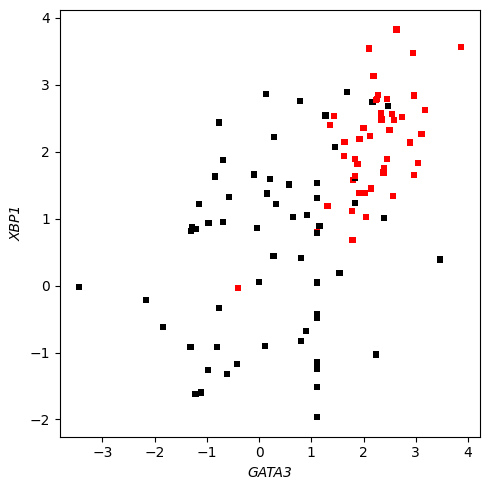

In [30]:
#  Figure 1a: GATA3 vs XBP1 scatter
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(gata3_expr, xbp1_expr, c=colors, marker='s', s=20, edgecolors='none')
ax.set_xlabel('GATA3', style='italic')
ax.set_ylabel('XBP1',  style='italic')
plt.tight_layout()
plt.savefig('figure1a.png', dpi=150)
plt.show()

In [31]:
# PCA on full expression matrix
scaler      = StandardScaler()
expr_scaled = scaler.fit_transform(expr)

pca  = PCA(n_components=2)
proj = pca.fit_transform(expr_scaled)
pc1  = proj[:, 0]

# Flip PC1 sign so ER+ (red) clusters on the right
er_pos_mask = labels['label'].values == 1
if pc1[er_pos_mask].mean() < pc1[~er_pos_mask].mean():
    pc1 = -pc1

er_pos = labels['label'].values == 1
er_neg = labels['label'].values == 0

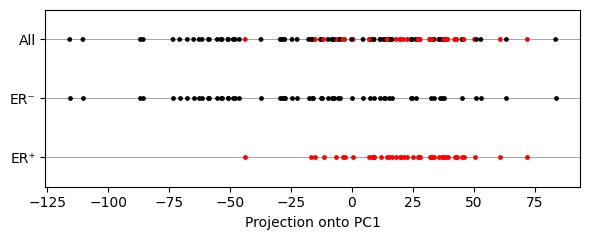

In [32]:
# Figure 1c: 1-D projection strip plot
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.scatter(pc1,         np.full(len(pc1), 2),    c=colors,  marker='o', s=12, linewidths=0)
ax.scatter(pc1[er_neg], np.full(er_neg.sum(), 1), c='black', marker='o', s=12, linewidths=0)
ax.scatter(pc1[er_pos], np.full(er_pos.sum(), 0), c='red',   marker='o', s=12, linewidths=0)

for y in [0, 1, 2]:
    ax.axhline(y, color='gray', linewidth=0.5, zorder=0)

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['ER⁺', 'ER⁻', 'All'])
ax.set_ylim(-0.5, 2.5)
ax.set_xlabel('Projection onto PC1')
plt.tight_layout()
plt.savefig('figure1c.png', dpi=150)
plt.show()
